In [11]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def compare_fitting_methods(df):
    """
    Compares the Robust Median Method vs. Non-Linear Least Squares.
    df: DataFrame with 'f' (Hz) and 'noise' (PSD in V/rtHz or similar)
    """
    f = df['f'].values
    n = df['noise'].values

    # --- Method 1: Your Robust Median Method ---
    # 1. nw estimate (using f > 300Hz)
    nw_robust = np.median(n[f > 300])
    
    # 2. fc estimate (using f < 2*fc_guess, let's say < 150Hz for the window)
    mask_low = (f > 0) & (f < 150)
    fc_points = f[mask_low] * ((n[mask_low]**2 / nw_robust**2) - 1)
    fc_robust = np.median(fc_points)

    # --- Method 2: Global Non-Linear Fit (Least Squares) ---
    # Define the model function: n(f) = nw * sqrt(1 + fc/f)
    def noise_model(freq, nw, fc):
        # We use absolute to prevent square roots of negative numbers during optimization
        return nw * np.sqrt(1 + np.abs(fc)/freq)

    try:
        # p0 is the initial guess: [mean_noise, 50Hz]
        popt, _ = curve_fit(noise_model, f, n, p0=[np.mean(n), 50])
        nw_lsq, fc_lsq = popt
    except Exception as e:
        nw_lsq, fc_lsq = np.nan, np.nan
        print(f"Least Squares failed: {e}")

    # --- Results Summary ---
    results = pd.DataFrame({
        "Parameter": ["White Noise (nw)", "Corner Freq (fc)"],
        "Robust Median": [nw_robust, fc_robust],
        "Least Squares": [nw_lsq, fc_lsq]
    })
    
    return results

# Example setup:
# data = pd.DataFrame({'f': frequencies, 'noise': psd_values})
# print(compare_fitting_methods(data))

data = pd.read_csv('Board_1_Results.txt', sep=r'\s+')
data.columns = ['f', 'noise']
results = compare_fitting_methods(data)
print(results)

          Parameter  Robust Median  Least Squares
0  White Noise (nw)       0.000038       0.000036
1  Corner Freq (fc)      29.021078      57.469850


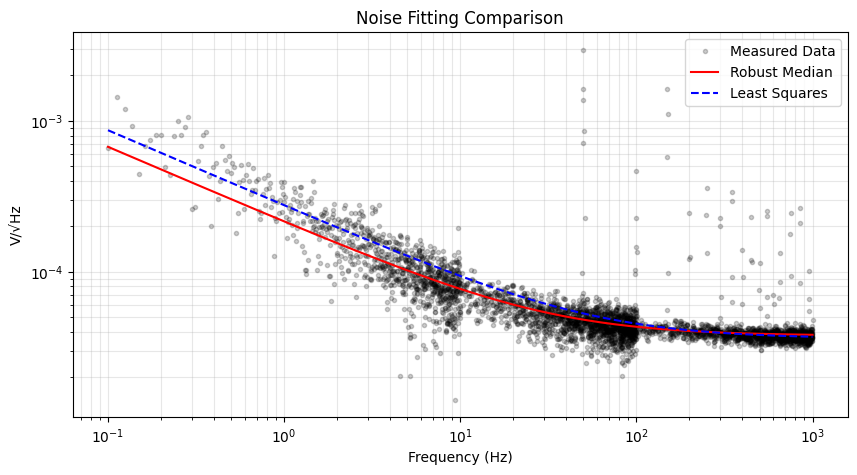

             Metric     Robust        LSQ
0  nw (White Noise)   0.000038   0.000036
1       fc (Corner)  31.825975  57.469850
2          MAPE (%)  22.803198  23.124185
3          Log-RMSE   0.127333   0.139760


In [12]:
def model_func(f, nw, fc):
    return nw * np.sqrt(1 + np.abs(fc)/f)

def run_comparison(df):
    f = df['f'].values
    n = df['noise'].values
    
    # --- METHOD 1: YOUR ROBUST MEDIAN ---
    # nw from high frequency (>300Hz)
    nw_r = np.median(n[f > 300])
    # fc from low frequency (<100Hz)
    mask = (f < 100) & (n > nw_r)
    fc_points = f[mask] * ((n[mask]**2 / nw_r**2) - 1)
    fc_r = np.median(fc_points)
    
    # --- METHOD 2: NON-LINEAR LEAST SQUARES ---
    try:
        popt, _ = curve_fit(model_func, f, n, p0=[np.mean(n), 50])
        nw_l, fc_l = popt
    except:
        nw_l, fc_l = np.nan, np.nan

    # --- ERROR CALCULATION ---
    def get_metrics(nw, fc):
        n_fit = model_func(f, nw, fc)
        mape = np.mean(np.abs((n - n_fit) / n_fit)) * 100
        rmse_log = np.sqrt(np.mean((np.log10(n) - np.log10(n_fit))**2))
        return mape, rmse_log

    mape_r, log_r = get_metrics(nw_r, fc_r)
    mape_l, log_l = get_metrics(nw_l, fc_l)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 5))
    plt.loglog(f, n, 'k.', alpha=0.2, label='Measured Data')
    
    f_highres = np.logspace(np.log10(f.min()), np.log10(f.max()), 500)
    plt.loglog(f_highres, model_func(f_highres, nw_r, fc_r), 'r-', label='Robust Median')
    plt.loglog(f_highres, model_func(f_highres, nw_l, fc_l), 'b--', label='Least Squares')
    
    plt.title('Noise Fitting Comparison')
    plt.xlabel('Frequency (Hz)'); plt.ylabel('V/√Hz')
    plt.legend(); plt.grid(True, which="both", alpha=0.3)
    plt.show()

    # Summary Table
    results = pd.DataFrame({
        "Metric": ["nw (White Noise)", "fc (Corner)", "MAPE (%)", "Log-RMSE"],
        "Robust": [nw_r, fc_r, mape_r, log_r],
        "LSQ": [nw_l, fc_l, mape_l, log_l]
    })
    return results

results = run_comparison(data)
print(results)